In [36]:
import numpy as np
import skfuzzy as fuzz
import skfuzzy.control as ctrl
import matplotlib.pyplot as plt

In [37]:
# Define input variables
traffic_density = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic_density')
waiting_time = ctrl.Antecedent(np.arange(0, 101, 1), 'waiting_time')

In [38]:
# Define output variables
green_light_duration = ctrl.Consequent(np.arange(0, 61, 1), 'green_light_duration')
red_light_duration = ctrl.Consequent(np.arange(0, 61, 1), 'red_light_duration')
yellow_light_duration = ctrl.Consequent(np.arange(3, 6, 1), 'yellow_light_duration')  # Typically fixed

In [39]:
# 1. Define Traffic Density (Input)
traffic_density['low'] = fuzz.trimf(traffic_density.universe, [0, 0, 50])
traffic_density['medium'] = fuzz.trimf(traffic_density.universe, [30, 50, 80])
traffic_density['high'] = fuzz.trimf(traffic_density.universe, [60, 100, 100])

In [40]:
# 2. Define Waiting Time (Input)
waiting_time['short'] = fuzz.trimf(waiting_time.universe, [0, 0, 40])
waiting_time['medium'] = fuzz.trimf(waiting_time.universe, [20, 50, 80])
waiting_time['long'] = fuzz.trimf(waiting_time.universe, [60, 100, 100])

In [41]:
# 3. Define Green Light Duration (Output)
green_light_duration['short'] = fuzz.trimf(green_light_duration.universe, [0, 0, 20])
green_light_duration['medium'] = fuzz.trimf(green_light_duration.universe, [10, 30, 50])
green_light_duration['long'] = fuzz.trimf(green_light_duration.universe, [40, 60, 60])

In [42]:
# 4. Define Red Light Duration (Output)
red_light_duration['short'] = fuzz.trimf(red_light_duration.universe, [0, 0, 20])
red_light_duration['medium'] = fuzz.trimf(red_light_duration.universe, [10, 30, 50])
red_light_duration['long'] = fuzz.trimf(red_light_duration.universe, [40, 60, 60])

In [43]:
# 5. Define Yellow Light Duration (Output)
yellow_light_duration['fixed'] = fuzz.trimf(yellow_light_duration.universe, [3, 4, 5])

In [44]:
# 1. Green Light Rules
rule1 = ctrl.Rule(traffic_density['low'] & waiting_time['short'], green_light_duration['short'])
rule2 = ctrl.Rule(traffic_density['low'] & waiting_time['medium'], green_light_duration['medium'])
rule3 = ctrl.Rule(traffic_density['low'] & waiting_time['long'], green_light_duration['medium'])

rule4 = ctrl.Rule(traffic_density['medium'] & waiting_time['short'], green_light_duration['medium'])
rule5 = ctrl.Rule(traffic_density['medium'] & waiting_time['medium'], green_light_duration['medium'])
rule6 = ctrl.Rule(traffic_density['medium'] & waiting_time['long'], green_light_duration['long'])

rule7 = ctrl.Rule(traffic_density['high'] & waiting_time['short'], green_light_duration['medium'])
rule8 = ctrl.Rule(traffic_density['high'] & waiting_time['medium'], green_light_duration['long'])
rule9 = ctrl.Rule(traffic_density['high'] & waiting_time['long'], green_light_duration['long'])

In [45]:
# 2. Red Light Rules (Opposite of Green)
rule10 = ctrl.Rule(traffic_density['low'], red_light_duration['long'])
rule11 = ctrl.Rule(traffic_density['medium'], red_light_duration['medium'])
rule12 = ctrl.Rule(traffic_density['high'], red_light_duration['short'])

In [46]:
# 3. Yellow Light Rules (Typically Fixed)
rule13 = ctrl.Rule(
    traffic_density['low'] | traffic_density['medium'] | traffic_density['high'],
    yellow_light_duration['fixed']
)

In [47]:
# Create the fuzzy control system
traffic_light_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9,
    rule10, rule11, rule12, rule13
])

traffic_light_simulation = ctrl.ControlSystemSimulation(traffic_light_ctrl)

In [48]:
# Example input values
traffic_density_value = 70
waiting_time_value = 50

traffic_light_simulation.input['traffic_density'] = traffic_density_value
traffic_light_simulation.input['waiting_time'] = waiting_time_value

In [49]:
# Compute the output (Inference + Defuzzification)
traffic_light_simulation.compute()

In [50]:
green = traffic_light_simulation.output['green_light_duration']
red = traffic_light_simulation.output['red_light_duration']
yellow = traffic_light_simulation.output['yellow_light_duration']

print("\n================ TRAFFIC SIGNAL OUTPUT ================\n")

print("Input Conditions:")
print("Traffic Density :", traffic_density_value)
print("Waiting Time    :", waiting_time_value)

print("\nCalculated Signal Timings:")

print(f"Green Light Duration  : {green:.2f} seconds")
print(f"Red Light Duration    : {red:.2f} seconds")
print(f"Yellow Light Duration : {yellow:.2f} seconds")

print("\n=======================================================")


================ TRAFFIC SIGNAL OUTPUT ================

Input Conditions:
Traffic Density : 70
Waiting Time    : 50

Calculated Signal Timings:
Green Light Duration  : 35.20 seconds
Red Light Duration    : 24.80 seconds
Yellow Light Duration : 4.00 seconds



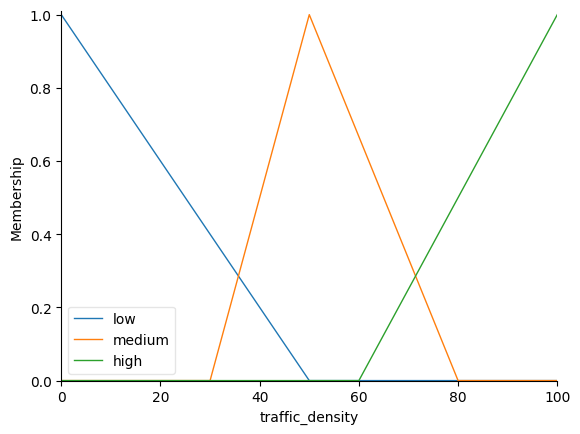

In [51]:
traffic_density.view()
plt.show()

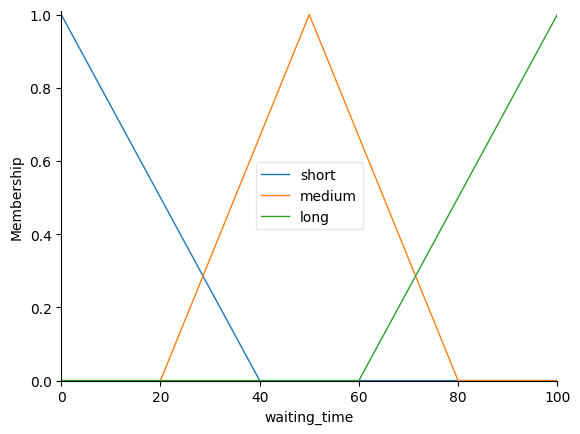

In [52]:
waiting_time.view()
plt.show()

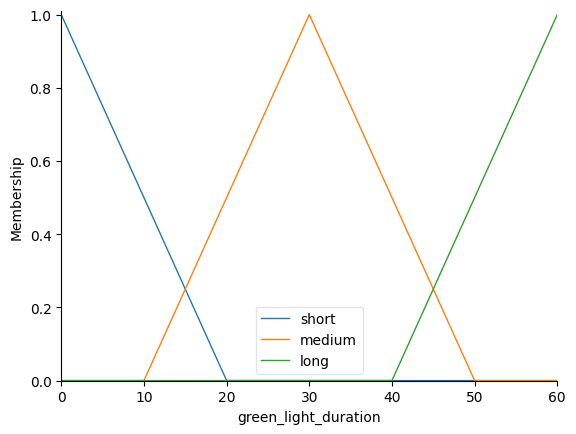

In [53]:
green_light_duration.view()
plt.show()

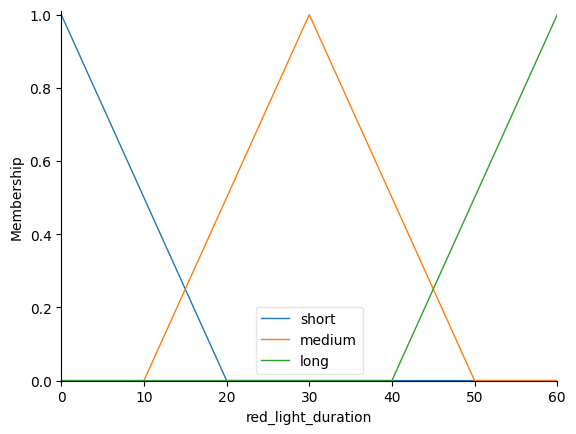

In [54]:
red_light_duration.view()
plt.show()

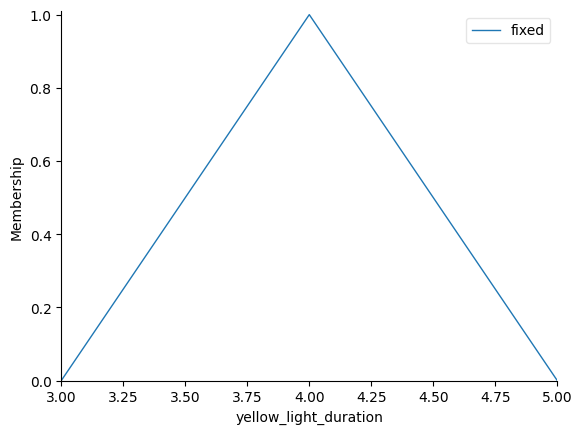

In [55]:
yellow_light_duration.view()
plt.show()